In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Customers.csv')

In [3]:
#1
df.head(10)
df.tail(10)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
1990,1991,Female,30,166983,69,Artist,7,3
1991,1992,Female,97,129444,96,Entertainment,5,6
1992,1993,Male,94,181183,24,Marketing,9,3
1993,1994,Female,64,175254,100,Artist,9,5
1994,1995,Female,19,54121,89,Engineer,6,3
1995,1996,Female,71,184387,40,Artist,8,7
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2
1998,1999,Male,77,182109,4,Executive,7,2
1999,2000,Male,90,110610,52,Entertainment,5,2


In [4]:
#2
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


In [5]:
#3
df.info()
df.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


,0
CustomerID,2000
Gender,2000
Age,2000
Annual Income ($),2000
Spending Score (1-100),2000
Profession,1965
Work Experience,2000
Family Size,2000


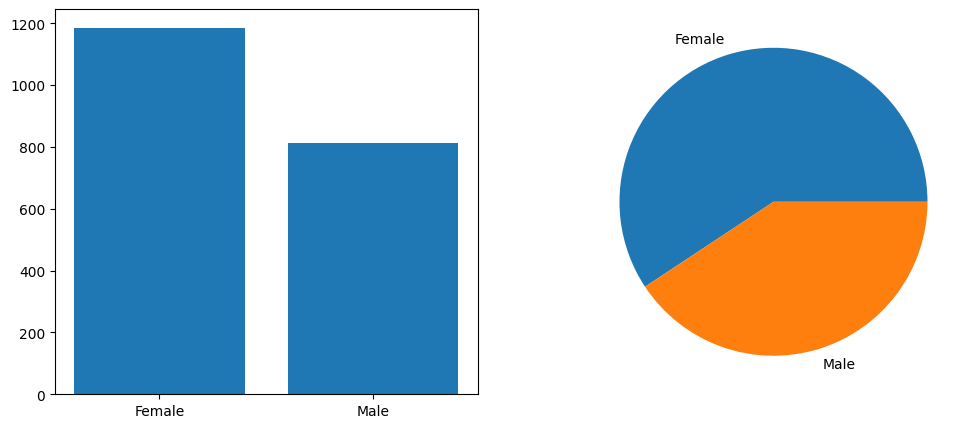

In [8]:
#4
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
gender_counts = df['Gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values)
plt.subplot(1,2,2)
plt.pie(gender_counts.values, labels=gender_counts.index)
plt.show()

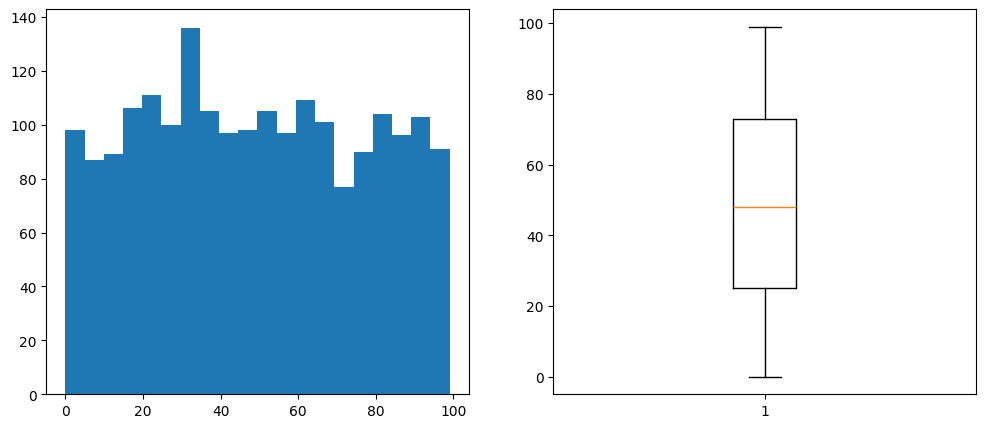

In [9]:
#5
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['Age'], bins=20)
plt.subplot(1,2,2)
plt.boxplot(df['Age'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

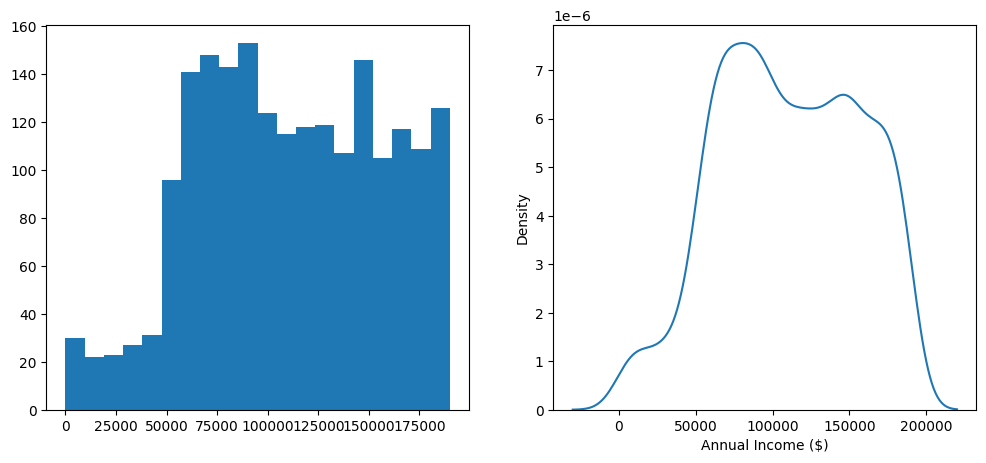

In [11]:
#6
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['Annual Income ($)'], bins=20)
plt.subplot(1,2,2)
sns.kdeplot(df['Annual Income ($)'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

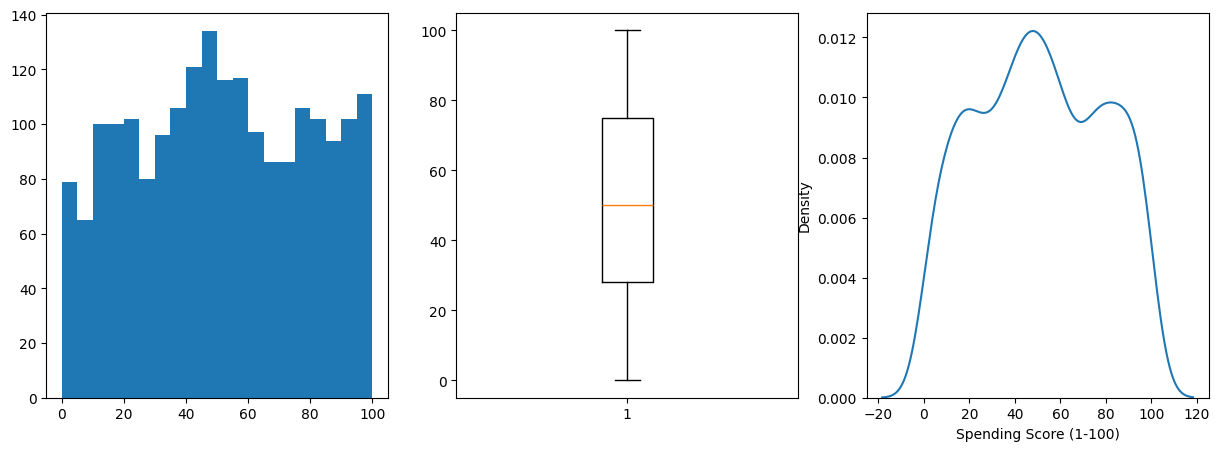

In [12]:
#7
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(df['Spending Score (1-100)'], bins=20)
plt.subplot(1,3,2)
plt.boxplot(df['Spending Score (1-100)'])
plt.subplot(1,3,3)
sns.kdeplot(df['Spending Score (1-100)'])
plt.show

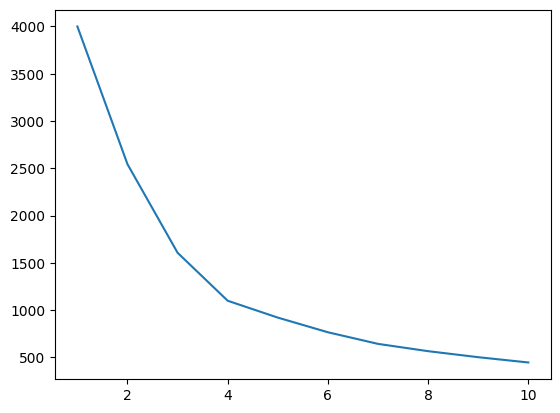

In [13]:
#8
X = df[['Annual Income ($)', 'Spending Score (1-100)']].dropna()
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)
inertia = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaler)
  inertia.append(kmeans.inertia_)
plt.plot(range(1,11), inertia)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

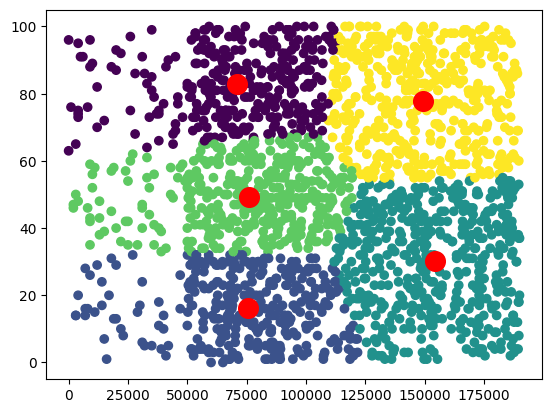

In [14]:
#9
kmeans = KMeans(n_clusters=5,random_state=42, n_init=10)
cluster = kmeans.fit_predict(X_scaler)
X_clustered = X.copy()
X_clustered['Cluster'] = cluster
plt.scatter(X_clustered['Annual Income ($)'], X_clustered['Spending Score (1-100)'], c = X_clustered['Cluster'])
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200)
plt.show